# GLOBAL HIERARCHY TESTS

The same plot will be made in cases where ~
    
   **NEQS=05/Lambda2:**
    
    Narrow: [1.4e-4,4.2e-4]
    Moderate: [-2.5e-3,2.5e-3]
    Kinney/Caliguri: [-5e-2,5e-2]
    Expanded:[-0.5,0.5]


   **NEQS=06/Lambda3:**
    
    Narrow: [-6.9e-6,-2.3e-6]
    Moderate:[-2.5e-5,2.5e-4]
    Kinney/Caliguri:[-5e-3,5e-3]
    Expanded:[-0.05,0.05]

   **NEQS=07/Lambda4:**
    
    Narrow:[3.4e-8,1.03e-7]
    Moderate:[-2.5e-6,2.5e-5]
    Kinney/Caliguri:[-5e-4,5e-4]
    Expanded:[-5e-3, 5e-3]

   **NEQS=08/Lambda5:**
    
    Narrow:[-4.46e-9,-1.34e-8]
    Moderate:[-2.5e-8,2.5e-6]
    Kinney/Caliguri:[-5e-5,5e-5]
    Expanded:[-5e-4, 5e-4]


Make specific imports:

In [1]:
import numpy
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')

import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
from matplotlib.gridspec import GridSpec

SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}


def plot_big_normalized_scan_summary(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    ref_floor_spec=1e-30,
    ref_floor_bg=1e-20,
    frac_floor=1e-100,
    H_scale=1.0,
    V_scale=1.0,
    cmap_name="plasma",
    save_name=None,
    suptitle=None,
    show=True,
):
    """
    Build one large figure containing:

      Row 1: normalized P_s(k), normalized P_t(k)
      Row 2: fractional error in normalized P_s(k), fractional error in normalized P_t(k)
      Row 3: normalized H(N), fractional error in normalized H(N)
      Row 4: normalized V(phi), fractional error in normalized V(phi)
      Row 5: summary stats table for Pt and H

    Definitions
    -----------
    Spectra are shape-normalized:
        P_s_norm(k) = P_s(k) / P_s(k_ref)
        P_t_norm(k) = P_t(k) / P_t(k_ref)

    Background curves are normalized at N_ref:
        H_norm(N)   = H(N) / H(N_ref)
        V_norm(phi) = V(phi) / V(N_ref)

    Error curves are fractional differences relative to the chosen base model:
        (curve - curve_base) / curve_base
    """

    def get_scan_info(neqs):
        if neqs not in SCAN_INFO:
            raise ValueError(f"Unsupported NEQS = {neqs}")
        return SCAN_INFO[neqs]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float
        )

    def prepare_increasing(x, y):
        """
        Accept monotonic x only.
        If fully decreasing, reverse x and y together.
        Refuse non-monotonic arrays.
        """
        x = np.asarray(x)
        y = np.asarray(y)

        if x.shape != y.shape:
            raise ValueError("x and y must have the same shape")

        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            raise ValueError(
                "x is not monotonic; refusing to reorder because that could distort physics."
            )

    def normalize_curve_at_ref(x, y, x_ref, ref_floor):
        x_use, y_use = prepare_increasing(x, y)

        if x_ref < np.min(x_use) or x_ref > np.max(x_use):
            raise ValueError(
                f"Reference x_ref={x_ref} outside range [{np.min(x_use)}, {np.max(x_use)}]"
            )

        y_ref = np.interp(x_ref, x_use, y_use)

        if np.abs(y_ref) < ref_floor:
            raise ValueError(
                f"Reference value too small for normalization at x_ref={x_ref}: {y_ref:.3e}"
            )

        return x_use, y_use / y_ref, y_ref

    def fractional_difference_on_common_x(x_base, y_base, x_cmp, y_cmp, floor=1e-100):
        """
        Evaluate:
            (y_cmp_interp - y_base) / y_base
        on the overlap, using the base grid.
        """
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xmin = max(np.min(x_base), np.min(x_cmp))
        xmax = min(np.max(x_base), np.max(x_cmp))

        mask = (x_base >= xmin) & (x_base <= xmax)
        x_use = x_base[mask]
        y_base_use = y_base[mask]
        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        denom = np.where(np.abs(y_base_use) > floor, y_base_use, np.nan)
        frac = (y_cmp_interp - y_base_use) / denom
        return x_use, frac

    def load_specs(value):
        val_str = f"{value:.1e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

        file_s = os.path.join(folder, f"spec_s{index:03d}_neqs{NEQS}.dat")
        file_t = os.path.join(folder, f"spec_t{index:03d}_neqs{NEQS}.dat")

        data_s = np.loadtxt(file_s)
        data_t = np.loadtxt(file_t)

        k_s = data_s[:, 0]
        Ps = np.abs(data_s[:, 1])

        k_t = data_t[:, 0]
        Pt = np.abs(data_t[:, 1])

        return k_s, Ps, k_t, Pt

    def load_path(value):
        val_str = f"{value:.1e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

        file_path = os.path.join(
            folder,
            f"path_neqs{NEQS}_{scan_name}{val_str}_{index:03d}.dat"
        )

        return pd.read_csv(file_path, sep=r"\s+", header=None).values

    def extract_cols(path_data):
        """
        Assumed column convention:
            phi = 0
            H   = 1
            N   = NEQS
            V   = NEQS + 1
        """
        phi = path_data[:, 0]
        H = path_data[:, 1]
        N = path_data[:, NEQS]
        V = path_data[:, NEQS + 1]
        return phi, H, N, V

    def get_normalized_H_vs_N(path_data):
        _, H, N, _ = extract_cols(path_data)
        N_use, H_norm, H_ref = normalize_curve_at_ref(N, H, N_ref, ref_floor_bg)
        return N_use, H_norm, H_ref

#     def get_normalized_V_vs_phi(path_data):
#         phi_raw, _, N_raw, V_raw = extract_cols(path_data)

#         # First use monotonic N ordering for physical trajectory order
#         N_use, phi_use = prepare_increasing(N_raw, phi_raw)
#         _, V_use = prepare_increasing(N_raw, V_raw)

#         if N_ref < np.min(N_use) or N_ref > np.max(N_use):
#             raise ValueError(
#                 f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
#             )

#         V_ref = np.interp(N_ref, N_use, V_use)

#         if np.abs(V_ref) < ref_floor_bg:
#             raise ValueError(
#                 f"Reference V(N_ref) too small at N_ref={N_ref}: {V_ref:.3e}"
#             )

#         V_norm = V_use / V_ref

    def get_normalized_V_vs_phi(path_data):
        phi_raw, _, N_raw, V_raw = extract_cols(path_data)

        N_use, phi_use = prepare_increasing(N_raw, phi_raw)
        _, V_use = prepare_increasing(N_raw, V_raw)


        if N_ref < np.min(N_use) or N_ref > np.max(N_use):
            raise ValueError(
                f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
            )

        V_ref = np.interp(N_ref, N_use, V_use)

        if np.abs(V_ref) < ref_floor_bg:
            raise ValueError(
                f"Reference V(N_ref) too small at N_ref={N_ref}: {V_ref:.3e}"
            )
        V_norm = V_use / V_ref

#         phi_plot, V_plot = prepare_increasing(phi_use, V_norm)
#         return phi_plot, V_plot, V_ref



        # Then prepare phi-space version
#         phi_plot, V_plot = prepare_increasing(phi_use, V_norm)
        
        phi_plot = phi_use
        V_plot = V_norm
        return phi_plot, V_plot, V_ref
   

    def setup_colorbar(fig, axes, lam_vals, scan_symbol, cmap_name="plasma"):
#         cmap = cm.get_cmap(cmap_name)
        import matplotlib as mpl
        cmap = mpl.colormaps[cmap_name]
        norm = mcolors.Normalize(vmin=np.min(lam_vals), vmax=np.max(lam_vals))
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)

        cbar = fig.colorbar(
            sm,
            ax=axes,
            orientation="vertical",
            fraction=0.015,
            pad=0.02
        )
        cbar.set_label(rf"${scan_symbol}$", fontsize=12)
        return cmap, norm

    # ---------------- setup ----------------
    scan_name, scan_symbol = get_scan_info(NEQS)
    lamX_numeric = sanitize_lam_values(lamX_values)

    # ---------------- base model ----------------
    try:
        k_s_base, Ps_base, k_t_base, Pt_base = load_specs(baseX)
        path_base = load_path(baseX)
    except FileNotFoundError as e:
        raise FileNotFoundError(
            f"Base model files not found for {scan_name} = {baseX:.5e}"
        ) from e

    k_s_base, Ps_base_norm, _ = normalize_curve_at_ref(
        k_s_base, Ps_base, k_ref, ref_floor_spec
    )
    k_t_base, Pt_base_norm, _ = normalize_curve_at_ref(
        k_t_base, Pt_base, k_ref, ref_floor_spec
    )

    N_H_base, H_base_norm, _ = get_normalized_H_vs_N(path_base)
    phi_V_base, V_base_norm, _ = get_normalized_V_vs_phi(path_base)

    # ---------------- figure ----------------
    fig = plt.figure(figsize=(18, 22), constrained_layout=True)
    gs = GridSpec(
        5, 2,
        figure=fig,
        height_ratios=[1.0, 1.0, 1.0, 1.0, 1.1]
    )

    ax_ps       = fig.add_subplot(gs[0, 0])
    ax_pt       = fig.add_subplot(gs[0, 1])
    ax_ps_err   = fig.add_subplot(gs[1, 0])
    ax_pt_err   = fig.add_subplot(gs[1, 1])
    ax_h        = fig.add_subplot(gs[2, 0])
    ax_h_err    = fig.add_subplot(gs[2, 1])
    ax_vphi     = fig.add_subplot(gs[3, 0])
    ax_vphi_err = fig.add_subplot(gs[3, 1])
    ax_table    = fig.add_subplot(gs[4, :])
    ax_table.axis("off")

    plot_axes = [ax_ps, ax_pt, ax_ps_err, ax_pt_err, ax_h, ax_h_err, ax_vphi, ax_vphi_err]
    cmap, norm = setup_colorbar(fig, plot_axes, lamX_numeric, scan_symbol, cmap_name=cmap_name)

    # ---------------- scan loop ----------------
    stats_rows = []

    for lamX in lamX_numeric:
        try:
            k_s, Ps, k_t, Pt = load_specs(lamX)
            path_data = load_path(lamX)

            # normalize spectra
            k_s_use, Ps_norm, _ = normalize_curve_at_ref(
                k_s, Ps, k_ref, ref_floor_spec
            )
            k_t_use, Pt_norm, _ = normalize_curve_at_ref(
                k_t, Pt, k_ref, ref_floor_spec
            )

            # normalize background
            N_H, H_norm, _ = get_normalized_H_vs_N(path_data)
            phi_V, V_norm, _ = get_normalized_V_vs_phi(path_data)

            color = cmap(norm(lamX))

            # fractional differences relative to base
            k_ps_err, frac_ps = fractional_difference_on_common_x(
                k_s_base, Ps_base_norm, k_s_use, Ps_norm, floor=frac_floor
            )
            k_pt_err, frac_pt = fractional_difference_on_common_x(
                k_t_base, Pt_base_norm, k_t_use, Pt_norm, floor=frac_floor
            )
            N_h_err, frac_h = fractional_difference_on_common_x(
                N_H_base, H_base_norm, N_H, H_norm, floor=frac_floor
            )
            phi_v_err, frac_v = fractional_difference_on_common_x(
                phi_V_base, V_base_norm, phi_V, V_norm, floor=frac_floor
            )

            # top/background plots
#             ax_ps.plot(k_s_use, Ps_norm, color=color, lw=1.6, alpha=0.9)
            k_max_scalar = 10.0
            mask_k = k_s_use <= k_max_scalar

            ax_ps.plot(
                k_s_use[mask_k],
                Ps_norm[mask_k],
                color=color,
                lw=1.6,
                alpha=0.9
            )
            ax_pt.plot(k_t_use, Pt_norm, color=color, lw=1.6, alpha=0.9)
            ax_h.plot(N_H, H_scale * H_norm, color=color, lw=1.6, alpha=0.9)
            ax_vphi.plot(phi_V, V_scale * V_norm, color=color, lw=1.6, alpha=0.9)

            # error plots
#             ax_ps_err.plot(k_ps_err, frac_ps, color=color, lw=1.6, alpha=0.9)
            mask_k_err = k_ps_err <= k_max_scalar

            ax_ps_err.plot(
                k_ps_err[mask_k_err],
                frac_ps[mask_k_err],
                color=color,
                lw=1.6,
                alpha=0.9
            )
            ax_pt_err.plot(k_pt_err, frac_pt, color=color, lw=1.6, alpha=0.9)
            ax_h_err.plot(N_h_err, frac_h, color=color, lw=1.6, alpha=0.9)
            ax_vphi_err.plot(phi_v_err, frac_v, color=color, lw=1.6, alpha=0.9)

            # summary table values
            mask_ps_stats = k_ps_err <= k_max_scalar
            frac_ps_use = frac_ps[mask_ps_stats]

            stats_rows.append({
                "lamX": lamX,

                # tensor (%)
                "mean_dPt_pct": 100 * np.nanmean(frac_pt),
                "max_dPt_pct": 100 * np.nanmax(np.abs(frac_pt)),

                # scalar (%), restricted k
                "mean_dPs_pct": 100 * np.nanmean(frac_ps_use),
                "max_dPs_pct": 100 * np.nanmax(np.abs(frac_ps_use)),

                # background (%)
                "mean_dH_pct": 100 * np.nanmean(frac_h),
                "max_dH_pct": 100 * np.nanmax(np.abs(frac_h)),

                "mean_dV_pct": 100 * np.nanmean(frac_v),
                "max_dV_pct": 100 * np.nanmax(np.abs(frac_v)),
            })

        except FileNotFoundError:
            print(f"Missing files for {scan_name} = {lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name} = {lamX:.5e}: {e}")

    stats_df = pd.DataFrame(stats_rows)

    # ---------------- titles ----------------
    ax_ps.set_title(
        rf"Normalized scalar spectrum: $\mathcal{{P}}_\mathcal{{R}}(k)/\mathcal{{P}}_\mathcal{{R}}({k_ref})$"
    )
    ax_pt.set_title(
        rf"Normalized tensor spectrum: $\mathcal{{P}}_t(k)/\mathcal{{P}}_t({k_ref})$"
    )

    ax_ps_err.set_title(r"Fractional error in normalized $\mathcal{P}_{\mathcal{R}}(k)$")
    ax_pt_err.set_title(r"Fractional error in normalized $\mathcal{P}_t(k)$")

    ax_h.set_title(rf"Normalized Hubble parameter: $H(N)/H({N_ref})$")
    ax_h_err.set_title(r"Fractional error in normalized $H(N)$")

    ax_vphi.set_title(rf"Normalized potential: $V(\phi)/V(N={N_ref})$")
    ax_vphi_err.set_title(r"Fractional error in normalized $V(\phi)$")

    # ---------------- y labels ----------------
    ax_ps.set_ylabel(r"$\mathcal{P}_{\mathcal{R},\mathrm{norm}}$")
    ax_pt.set_ylabel(r"$\mathcal{P}_{t,\mathrm{norm}}$")

    ax_ps_err.set_ylabel(
        r"$\left(\mathcal{P}_{\mathcal{R},\mathrm{norm}}-\mathcal{P}_{\mathcal{R},\mathrm{base}}\right)/\mathcal{P}_{\mathcal{R},\mathrm{base}}$"
    )
    ax_pt_err.set_ylabel(
        r"$\left(\mathcal{P}_{t,\mathrm{norm}}-\mathcal{P}_{t,\mathrm{base}}\right)/\mathcal{P}_{t,\mathrm{base}}$"
    )

    if H_scale == 1.0:
      
        ax_h.set_ylabel(r"$H/H(N_{\mathrm{ref}})$")
    else:
#         ax_h.set_ylabel(rf"${H_scale:.0e}\,H/H(N_{{\mathrm{{ref}}}})$")
        ax_h.set_ylabel(rf"$10^{6}H/H(N_{{\mathrm{{ref}}}})$")


    ax_h_err.set_ylabel(
        r"$\left(H_{\mathrm{norm}}-H_{\mathrm{base}}\right)/H_{\mathrm{base}}$"
    )

    if V_scale == 1.0:
        ax_vphi.set_ylabel(r"$V/V(N_{\mathrm{ref}})$")
    else:
#         ax_vphi.set_ylabel(rf"${V_scale:.0e}\,V/V(N_{{\mathrm{{ref}}}})$")
        ax_vphi.set_ylabel(rf"$10^{{13}}H/H(N_{{\mathrm{{ref}}}})$")


    ax_vphi_err.set_ylabel(
        r"$\left(V_{\mathrm{norm}}-V_{\mathrm{base}}\right)/V_{\mathrm{base}}$"
    )

    # ---------------- x labels ----------------
    ax_ps_err.set_xlabel(r"$k \,[h\,\mathrm{Mpc}^{-1}]$")
    ax_pt_err.set_xlabel(r"$k \,[h\,\mathrm{Mpc}^{-1}]$")
    ax_h.set_xlabel(r"$N$")
    ax_h_err.set_xlabel(r"$N$")
    ax_vphi.set_xlabel(r"$\phi$")
    ax_vphi_err.set_xlabel(r"$\phi$")

    # ---------------- styling ----------------
    # spectra: log x and log y
    for ax in [ax_ps, ax_pt]:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.25)
        ax.minorticks_on()

    # spectra errors: log x only
    for ax in [ax_ps_err, ax_pt_err]:
        ax.set_xscale("log")
        ax.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
        ax.grid(True, alpha=0.25)
        ax.minorticks_on()

    # H plot: inverted x and log y
    ax_h.invert_xaxis()
#     ax_h.set_yscale("log")
    ax_h.grid(True, alpha=0.25)

    # H error: inverted x, linear y
    ax_h_err.invert_xaxis()
    ax_h_err.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax_h_err.grid(True, alpha=0.25)

    # V(phi) plot: inverted x and log y
#     ax_vphi.invert_xaxis()
#     ax_vphi.set_yscale("log")
    ax_vphi.grid(True, alpha=0.25)

    # V(phi) error: inverted x, linear y
#     ax_vphi_err.invert_xaxis()
    ax_vphi_err.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax_vphi_err.grid(True, alpha=0.25)
# ---------------- simple printed summary ----------------
    ax_table.set_visible(False)

    ax_table.set_visible(False)

    if not stats_df.empty:
        print("\n=== Summary Statistics (% difference from base) ===\n")

        display_df = stats_df.copy()

        for col in display_df.columns:
            if col == "lamX":
                display_df[col] = display_df[col].map(lambda x: f"{x:.2e}")
            else:
                display_df[col] = display_df[col].map(lambda x: f"{x:.3f}%")

        print(display_df.to_string(index=False))
    else:
        print("\nNo valid models loaded.\n")

    # ---------------- title / save ----------------
    if suptitle is None:
        suptitle = (
            rf"Normalized spectra and background summary for NEQS={NEQS} "
            rf"(${scan_symbol}$ scan, base = {baseX:.2e})"
        )
    fig.suptitle(suptitle, fontsize=17)

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_big_normalized_summary.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)
        
    phi, H, N, V = extract_cols(path_base)

    print("phi at max N:", phi[np.argmax(N)])
    print("phi at min N:", phi[np.argmin(N)])

    return stats_df

In [ ]:
def get_param_values_from_dirs(NEQS, param_name, base_path_root, show_summary=True):
    """
    Scan directories for parameter values and optionally show summary statistics
    
    Parameters:
    -----------
    NEQS : int
        Number of equations (e.g., 6, 7, 8)
    param_name : str
        Parameter name (e.g., "lam3", "lam4")
    base_path_root : str
        Root path to search -- specific to where shit is saved
    show_summary : bool
        If True, print summary information about models found
    
    Returns:
    --------
    list of tuples **this is important the face that it is tuples**
        [(value, label), ...] for each parameter value found
    """
    
    #We will have to define the base_path_root first where the neqs files live
    base_path = f"{base_path_root}/neqs{NEQS}"
    #Once the path is defined, we will create search pattern for directories with param_name should be lamX
    pattern = os.path.join(base_path, f"{param_name}_*")
    #Glob will find all dirs that match serarch pattern
    dirs = glob.glob(pattern)

    #Initialize a values list:
    values = []
    #Then for every directory corresponding to search pattern we will do...
    for d in dirs:
        try:
            # lam3_-4.6e-06 → "-4.6e-06"
            #extract basename of directory and split it with underscores to get the second part
            val_str = os.path.basename(d).split("_")[1] #basename bit
            val = float(val_str) #string
            label = rf"${param_name} = {val:.1e}$"
            values.append((val, label)) #creates tuple of value and label and adds it to list 
        except Exception as e: #if we dont get the directory name with expected format, it will skip
            print(f"Skipping {d}: {e}")
    
    # Then we can sort by parameter value (first value in each tuple)
    #I believe this sorting should be fine we are just organizing the values of lamX that have already ran
    values.sort(key=lambda x: x[0])
    
    #We can print a summary if we want
    if show_summary:
        print(f"\n{'='*60}")
        print(f"Summary for NEQS={NEQS}, parameter={param_name}")
        print(f"{'='*60}")
        print(f"Total models found: {len(values)}")
        print(f"Parameter range: {values[0][0]:.3e} to {values[-1][0]:.3e}")
        print(f"{'='*60}\n")
    
    return values

## NEQs = 5 and $\lambda_2$:


Summary for NEQS=5, parameter=lam2
Total models found: 39
Parameter range: -2.400e-03 to 2.400e-03

Missing files for lam2 = -2.40000e-03
Missing files for lam2 = -2.30000e-03
Missing files for lam2 = -2.10000e-03
Missing files for lam2 = -2.00000e-03
Missing files for lam2 = -1.90000e-03
Missing files for lam2 = -1.80000e-03
Missing files for lam2 = -1.70000e-03
Missing files for lam2 = -1.40000e-03
Missing files for lam2 = -1.30000e-03
Missing files for lam2 = -1.10000e-03
Missing files for lam2 = -9.50000e-04
Missing files for lam2 = -8.80000e-04
Missing files for lam2 = -7.80000e-04
Missing files for lam2 = -7.70000e-04
Missing files for lam2 = -7.40000e-04
Missing files for lam2 = -5.50000e-04
Missing files for lam2 = -5.20000e-04
Missing files for lam2 = -4.60000e-04
Missing files for lam2 = -4.20000e-04
Missing files for lam2 = -4.10000e-04
Missing files for lam2 = -2.20000e-04

=== Summary Statistics (% difference from base) ===

     lamX mean_dPt_pct max_dPt_pct mean_dPs_pct

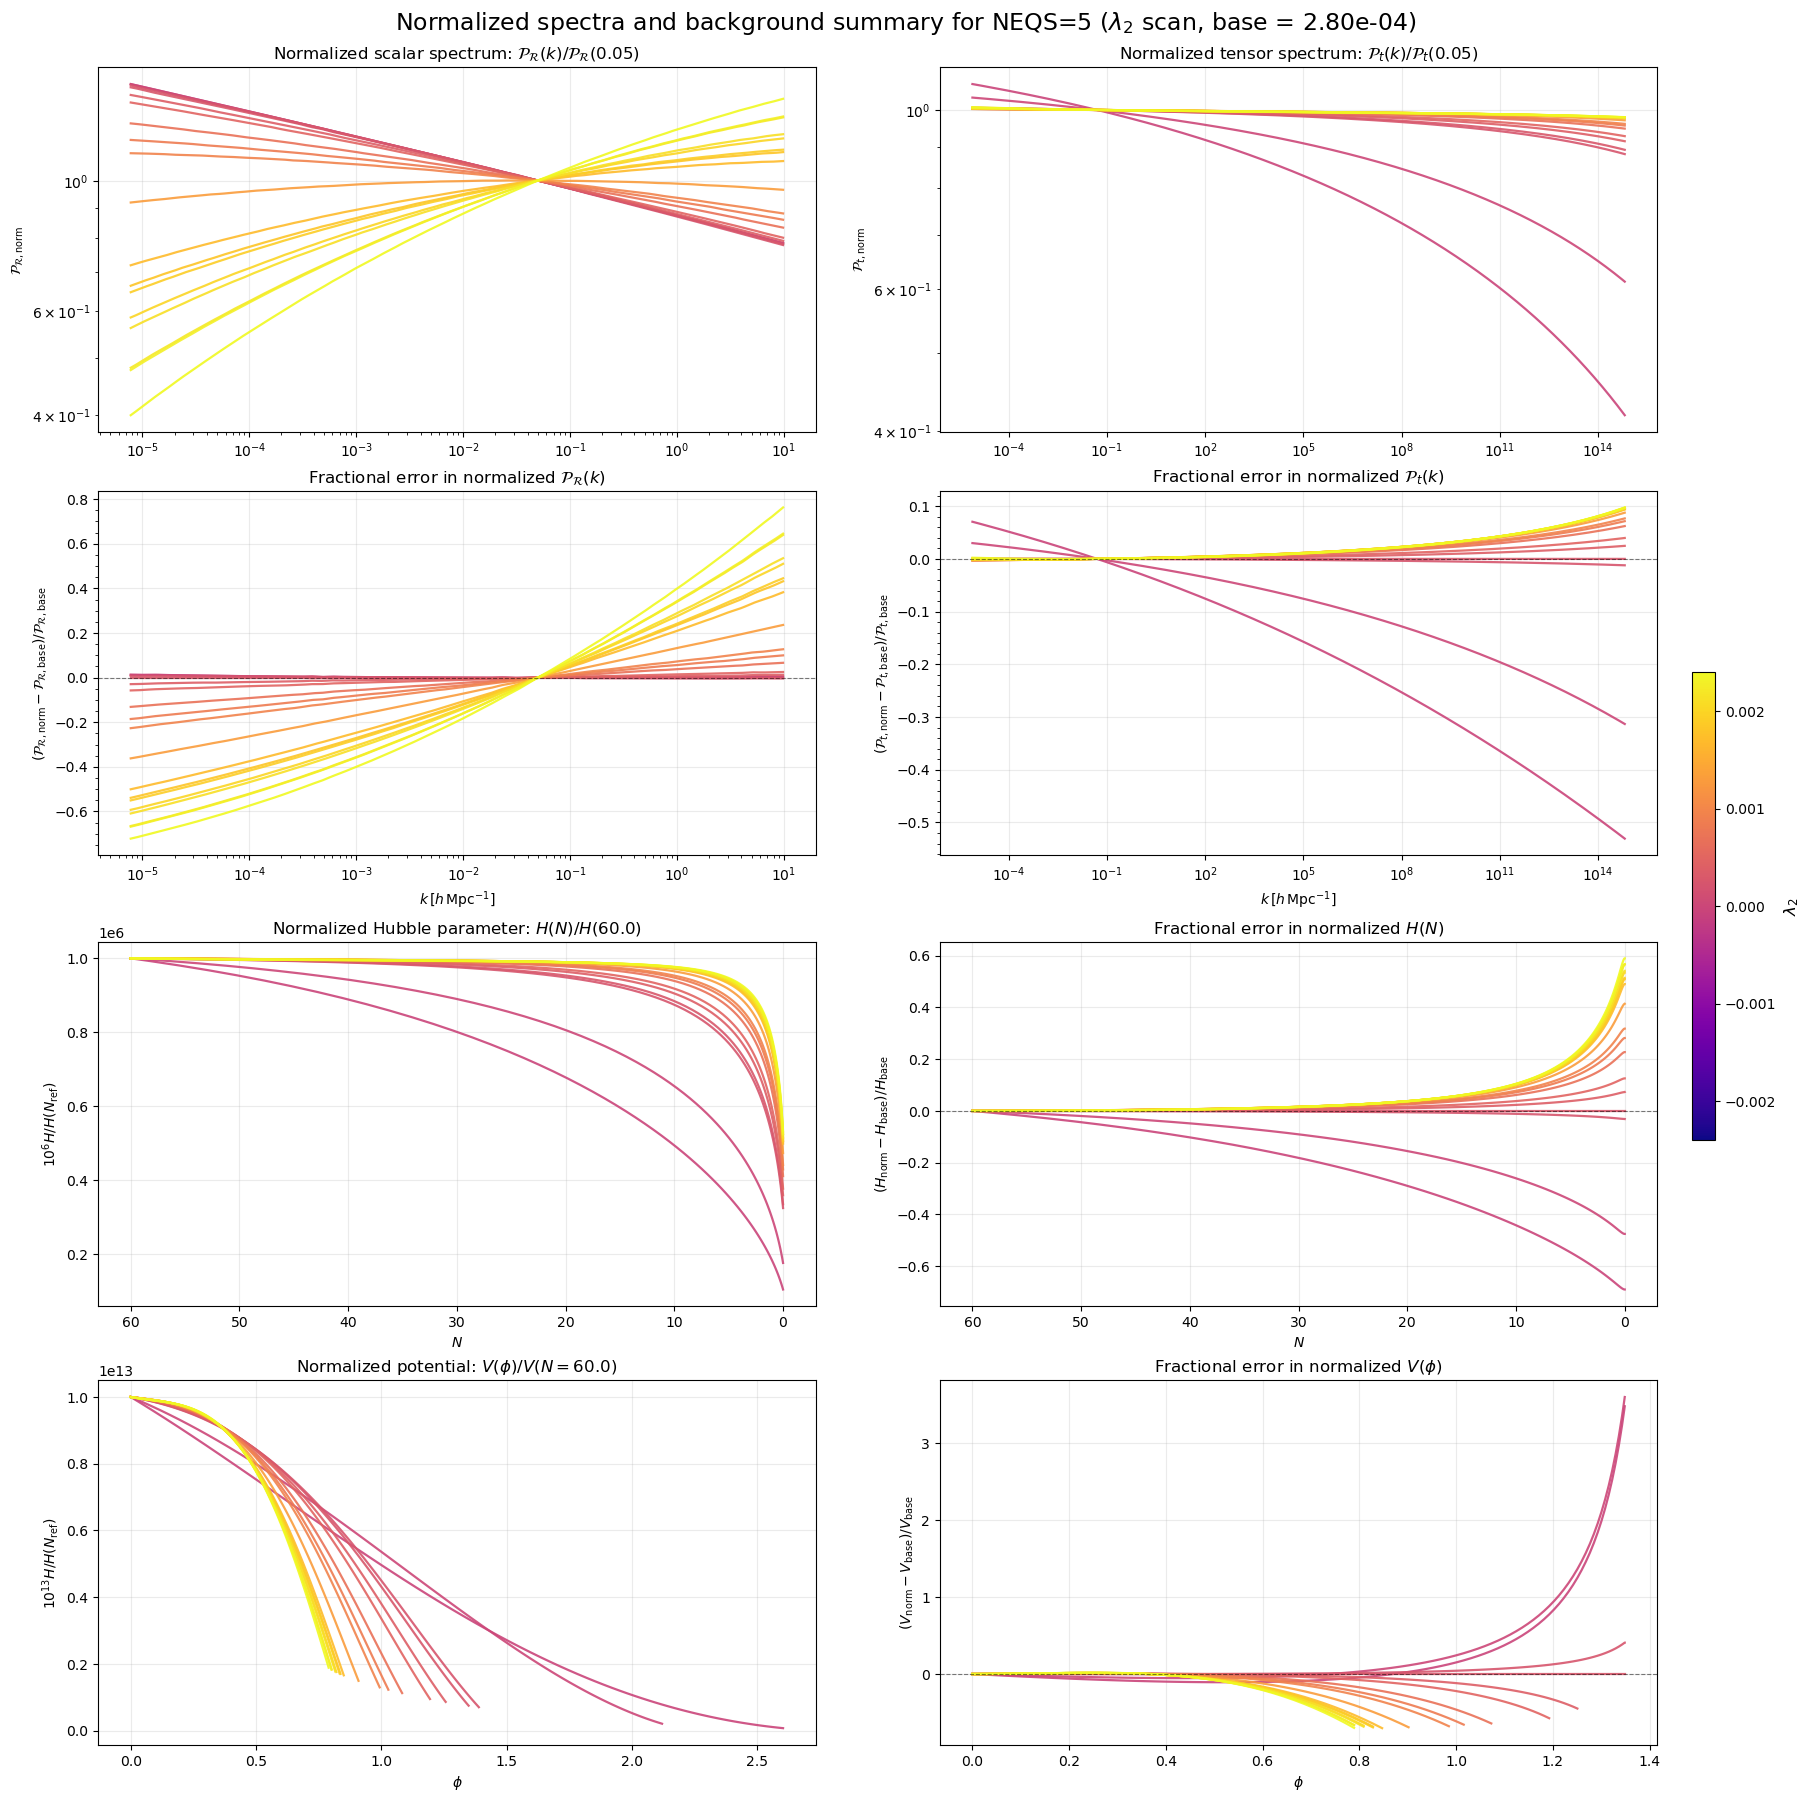

phi at max N: 0.0
phi at min N: 1.348593
        lamX  mean_dPt_pct  max_dPt_pct  mean_dPs_pct  max_dPs_pct  \
0  -0.000024    -17.864906    53.062232      0.242423     1.231935   
1   0.000000     -9.530550    31.317168      0.283606     1.288740   
2   0.000240     -0.305739     1.214591      0.056480     0.750222   
3   0.000280      0.000000     0.000000      0.000000     0.000000   
4   0.000380      0.603038     2.473034     -0.650574     2.939312   
5   0.000470      0.953649     3.967393     -1.226340     5.752537   
6   0.000690      1.460668     6.225736     -2.760405    13.131053   
7   0.000840      1.659485     7.155175     -3.856320    18.561937   
8   0.000950      1.768546     7.681156     -4.677993    22.675063   
9   0.001300      1.980657     8.765741     -7.230545    36.206397   
10  0.001700      2.078697     9.353105     -9.612884    50.068933   
11  0.001800      2.092980     9.461259    -10.211253    53.903427   
12  0.001900      2.096316     9.489552    -10.44

In [33]:

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam2_values = get_param_values_from_dirs(5, "lam2", base_path_root)


stats_df = plot_big_normalized_scan_summary(
    NEQS=5,
    lamX_values=lam2_values,
    baseX=2.8e-04,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    H_scale=1e6,     
    V_scale=1e13,    
    save_name="kinney_neqs5_lam2_big_summary.png"
)

print(stats_df)

## NEQs = 6 and $\lambda_3$:


Summary for NEQS=6, parameter=lam3
Total models found: 38
Parameter range: -1.700e-05 to 2.500e-04

Missing files for lam3 = 1.20000e-05
Missing files for lam3 = 1.50000e-05
Missing files for lam3 = 1.90000e-05
Missing files for lam3 = 3.40000e-05
Missing files for lam3 = 3.70000e-05
Missing files for lam3 = 4.30000e-05
Missing files for lam3 = 4.70000e-05
Missing files for lam3 = 5.00000e-05
Missing files for lam3 = 5.60000e-05
Missing files for lam3 = 6.00000e-05
Missing files for lam3 = 7.20000e-05
Missing files for lam3 = 7.80000e-05
Missing files for lam3 = 7.90000e-05
Missing files for lam3 = 8.10000e-05
Missing files for lam3 = 8.30000e-05
Missing files for lam3 = 8.40000e-05
Missing files for lam3 = 8.50000e-05
Missing files for lam3 = 9.10000e-05
Missing files for lam3 = 1.10000e-04
Missing files for lam3 = 1.20000e-04
Missing files for lam3 = 1.30000e-04
Missing files for lam3 = 1.40000e-04
Missing files for lam3 = 1.50000e-04
Missing files for lam3 = 1.60000e-04
Missing fil

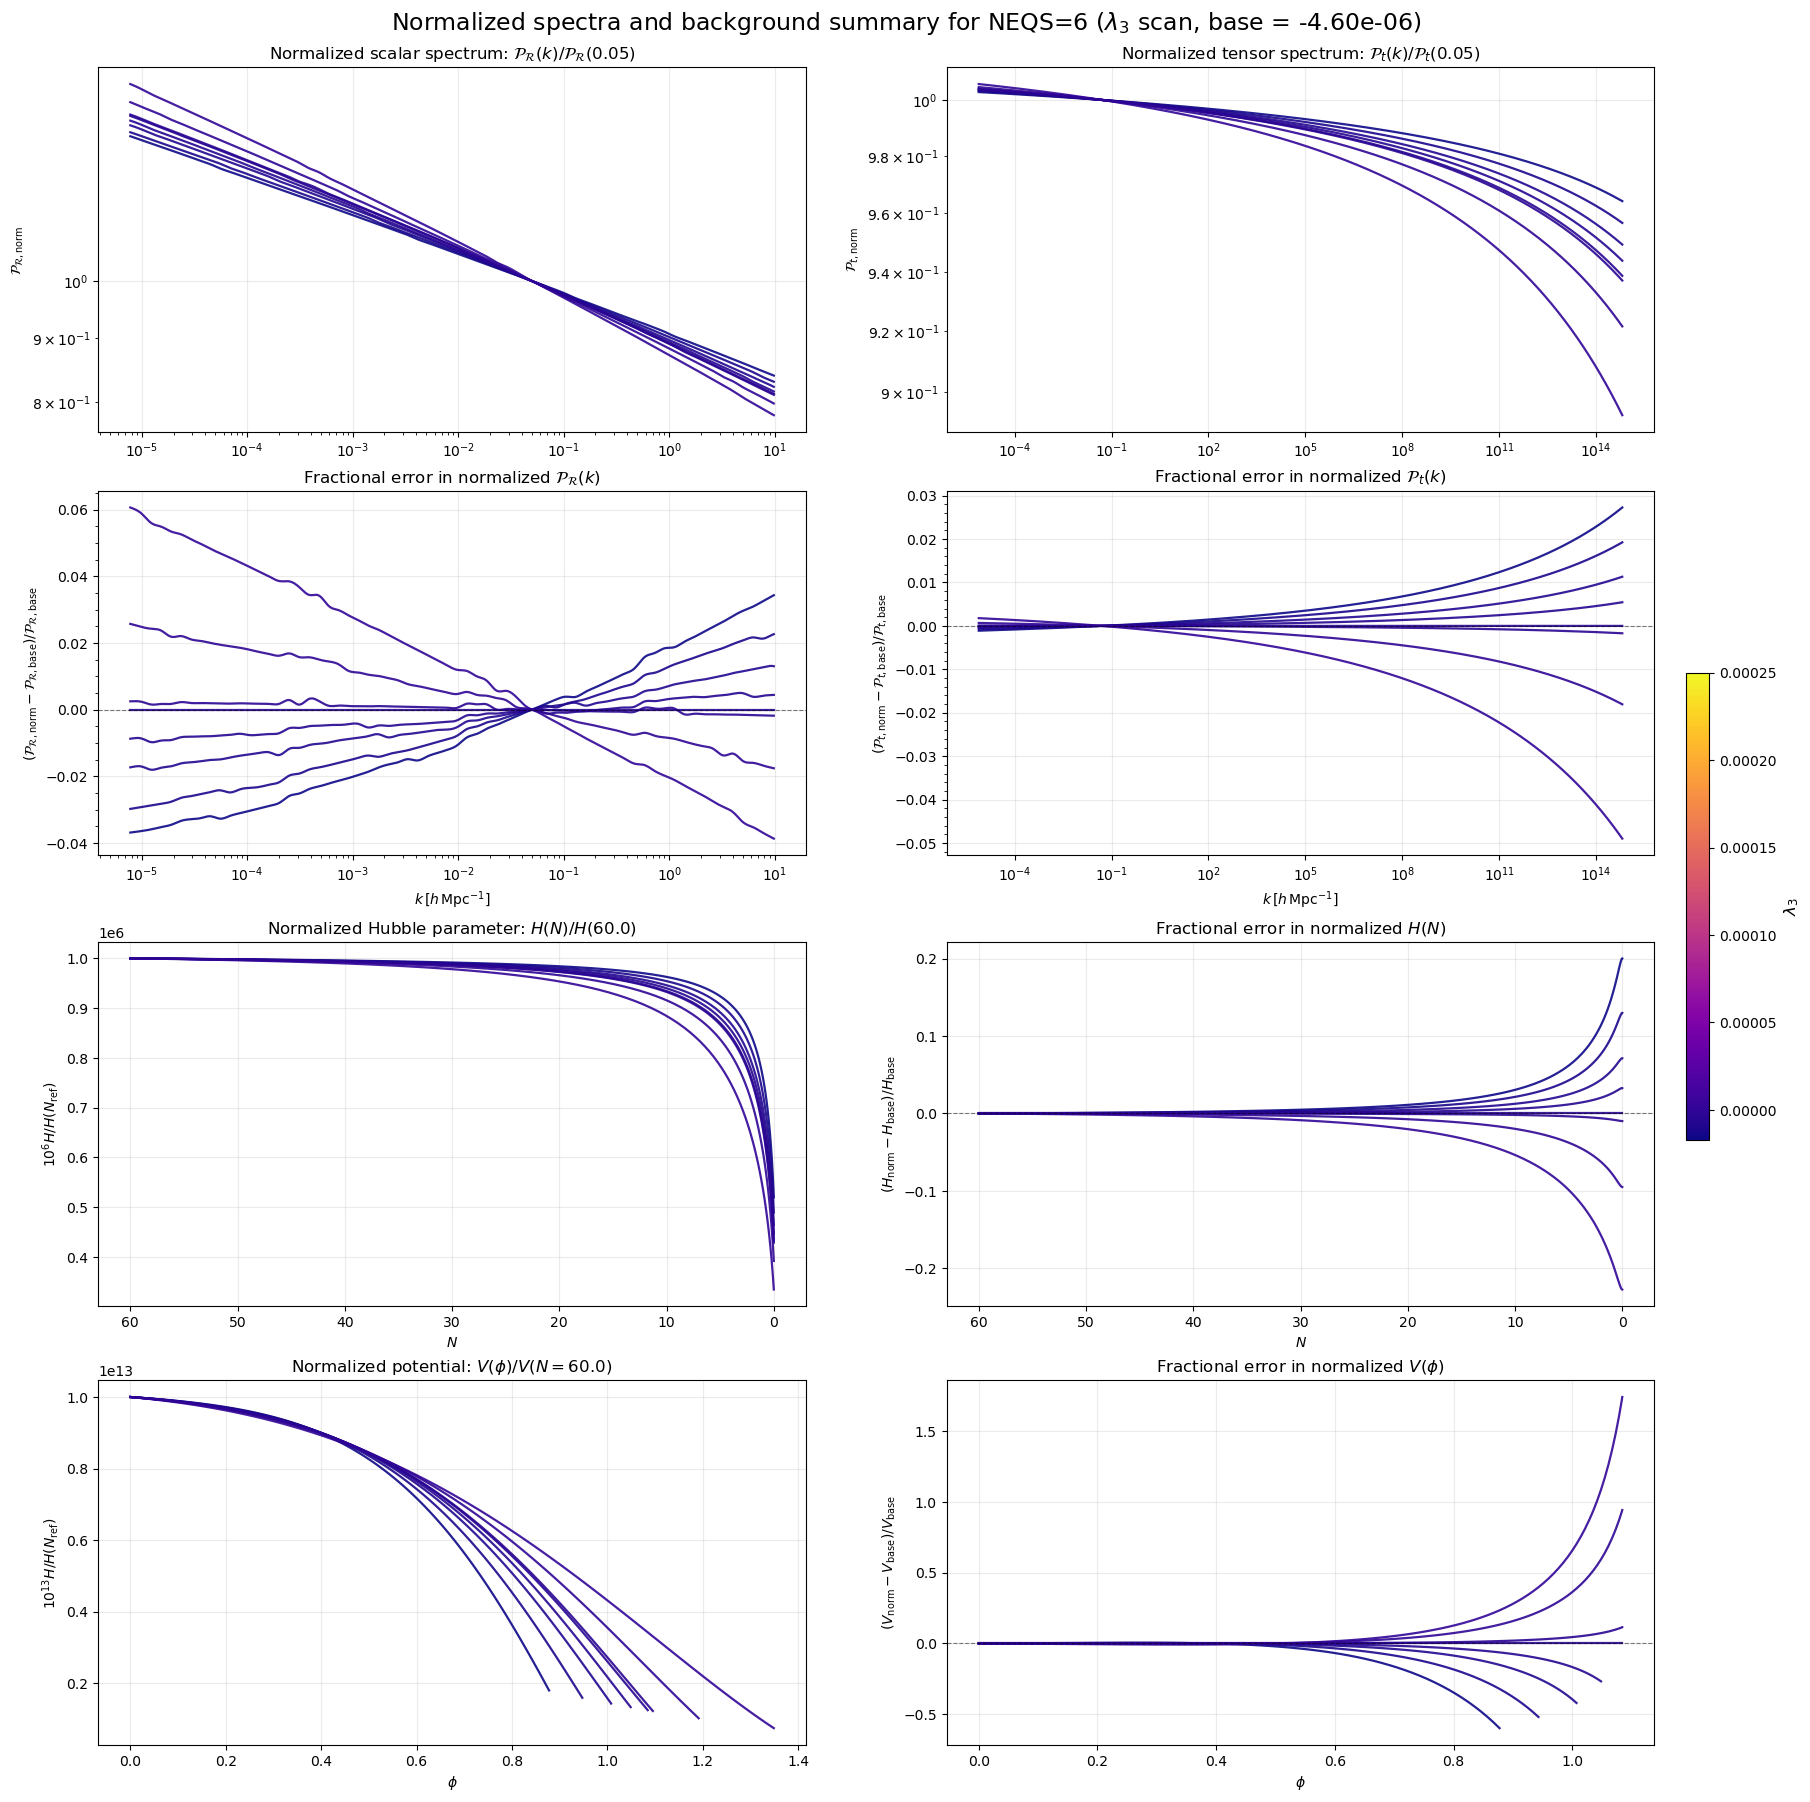

phi at max N: 0.0
phi at min N: 1.084339
       lamX  mean_dPt_pct  max_dPt_pct  mean_dPs_pct  max_dPs_pct  \
0 -0.000017      0.610352     2.726860     -0.728721     3.686088   
1 -0.000011      0.430635     1.924098     -0.620799     2.976874   
2 -0.000008      0.253340     1.132031     -0.389676     1.803212   
3 -0.000006      0.121860     0.544616     -0.256359     0.977303   
4 -0.000005      0.000000     0.000000      0.000000     0.000000   
5 -0.000004     -0.038003     0.169833      0.061373     0.336372   
6 -0.000002     -0.403770     1.805386      0.498504     2.570455   
7  0.000000     -1.093463     4.897367      1.218883     6.061154   

   mean_dH_pct  max_dH_pct  mean_dV_pct  max_dV_pct  
0     9.012181   20.035641   -10.207776   59.860071  
1     5.976744   12.994014    -8.946637   51.968104  
2     3.341124    7.137732    -7.108752   42.052964  
3     1.553079    3.285861    -4.334162   26.786580  
4     0.000000    0.000000     0.000000    0.000000  
5    -0.47205

In [34]:

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam3_values = get_param_values_from_dirs(6, "lam3", base_path_root)


stats_df = plot_big_normalized_scan_summary(
    NEQS=6,
    lamX_values=lam3_values,
    baseX=-4.6e-6,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    H_scale=1e6,    
    V_scale=1e13,    
    save_name="kinney_neqs6_lam3_big_summary.png"
)

print(stats_df)

## NEQs = 7 and $\lambda_4$:


Summary for NEQS=7, parameter=lam4
Total models found: 29
Parameter range: 0.000e+00 to 1.000e-07

Missing files for lam4 = 3.90000e-08
Missing files for lam4 = 4.10000e-08
Missing files for lam4 = 4.50000e-08
Missing files for lam4 = 4.90000e-08
Missing files for lam4 = 5.50000e-08
Missing files for lam4 = 5.80000e-08
Missing files for lam4 = 6.40000e-08
Missing files for lam4 = 7.20000e-08
Missing files for lam4 = 7.40000e-08
Missing files for lam4 = 9.10000e-08

=== Summary Statistics (% difference from base) ===

    lamX mean_dPt_pct max_dPt_pct mean_dPs_pct max_dPs_pct mean_dH_pct max_dH_pct mean_dV_pct max_dV_pct
0.00e+00      -0.215%      1.029%       0.366%      1.543%     -4.528%    10.239%     13.912%    79.622%
3.70e-08      -0.081%      0.382%       0.266%      0.697%     -1.697%     3.824%      6.311%    35.881%
4.20e-08      -0.066%      0.311%       0.196%      0.589%     -1.380%     3.113%      5.254%    29.847%
4.30e-08      -0.064%      0.300%       0.189%      0.57

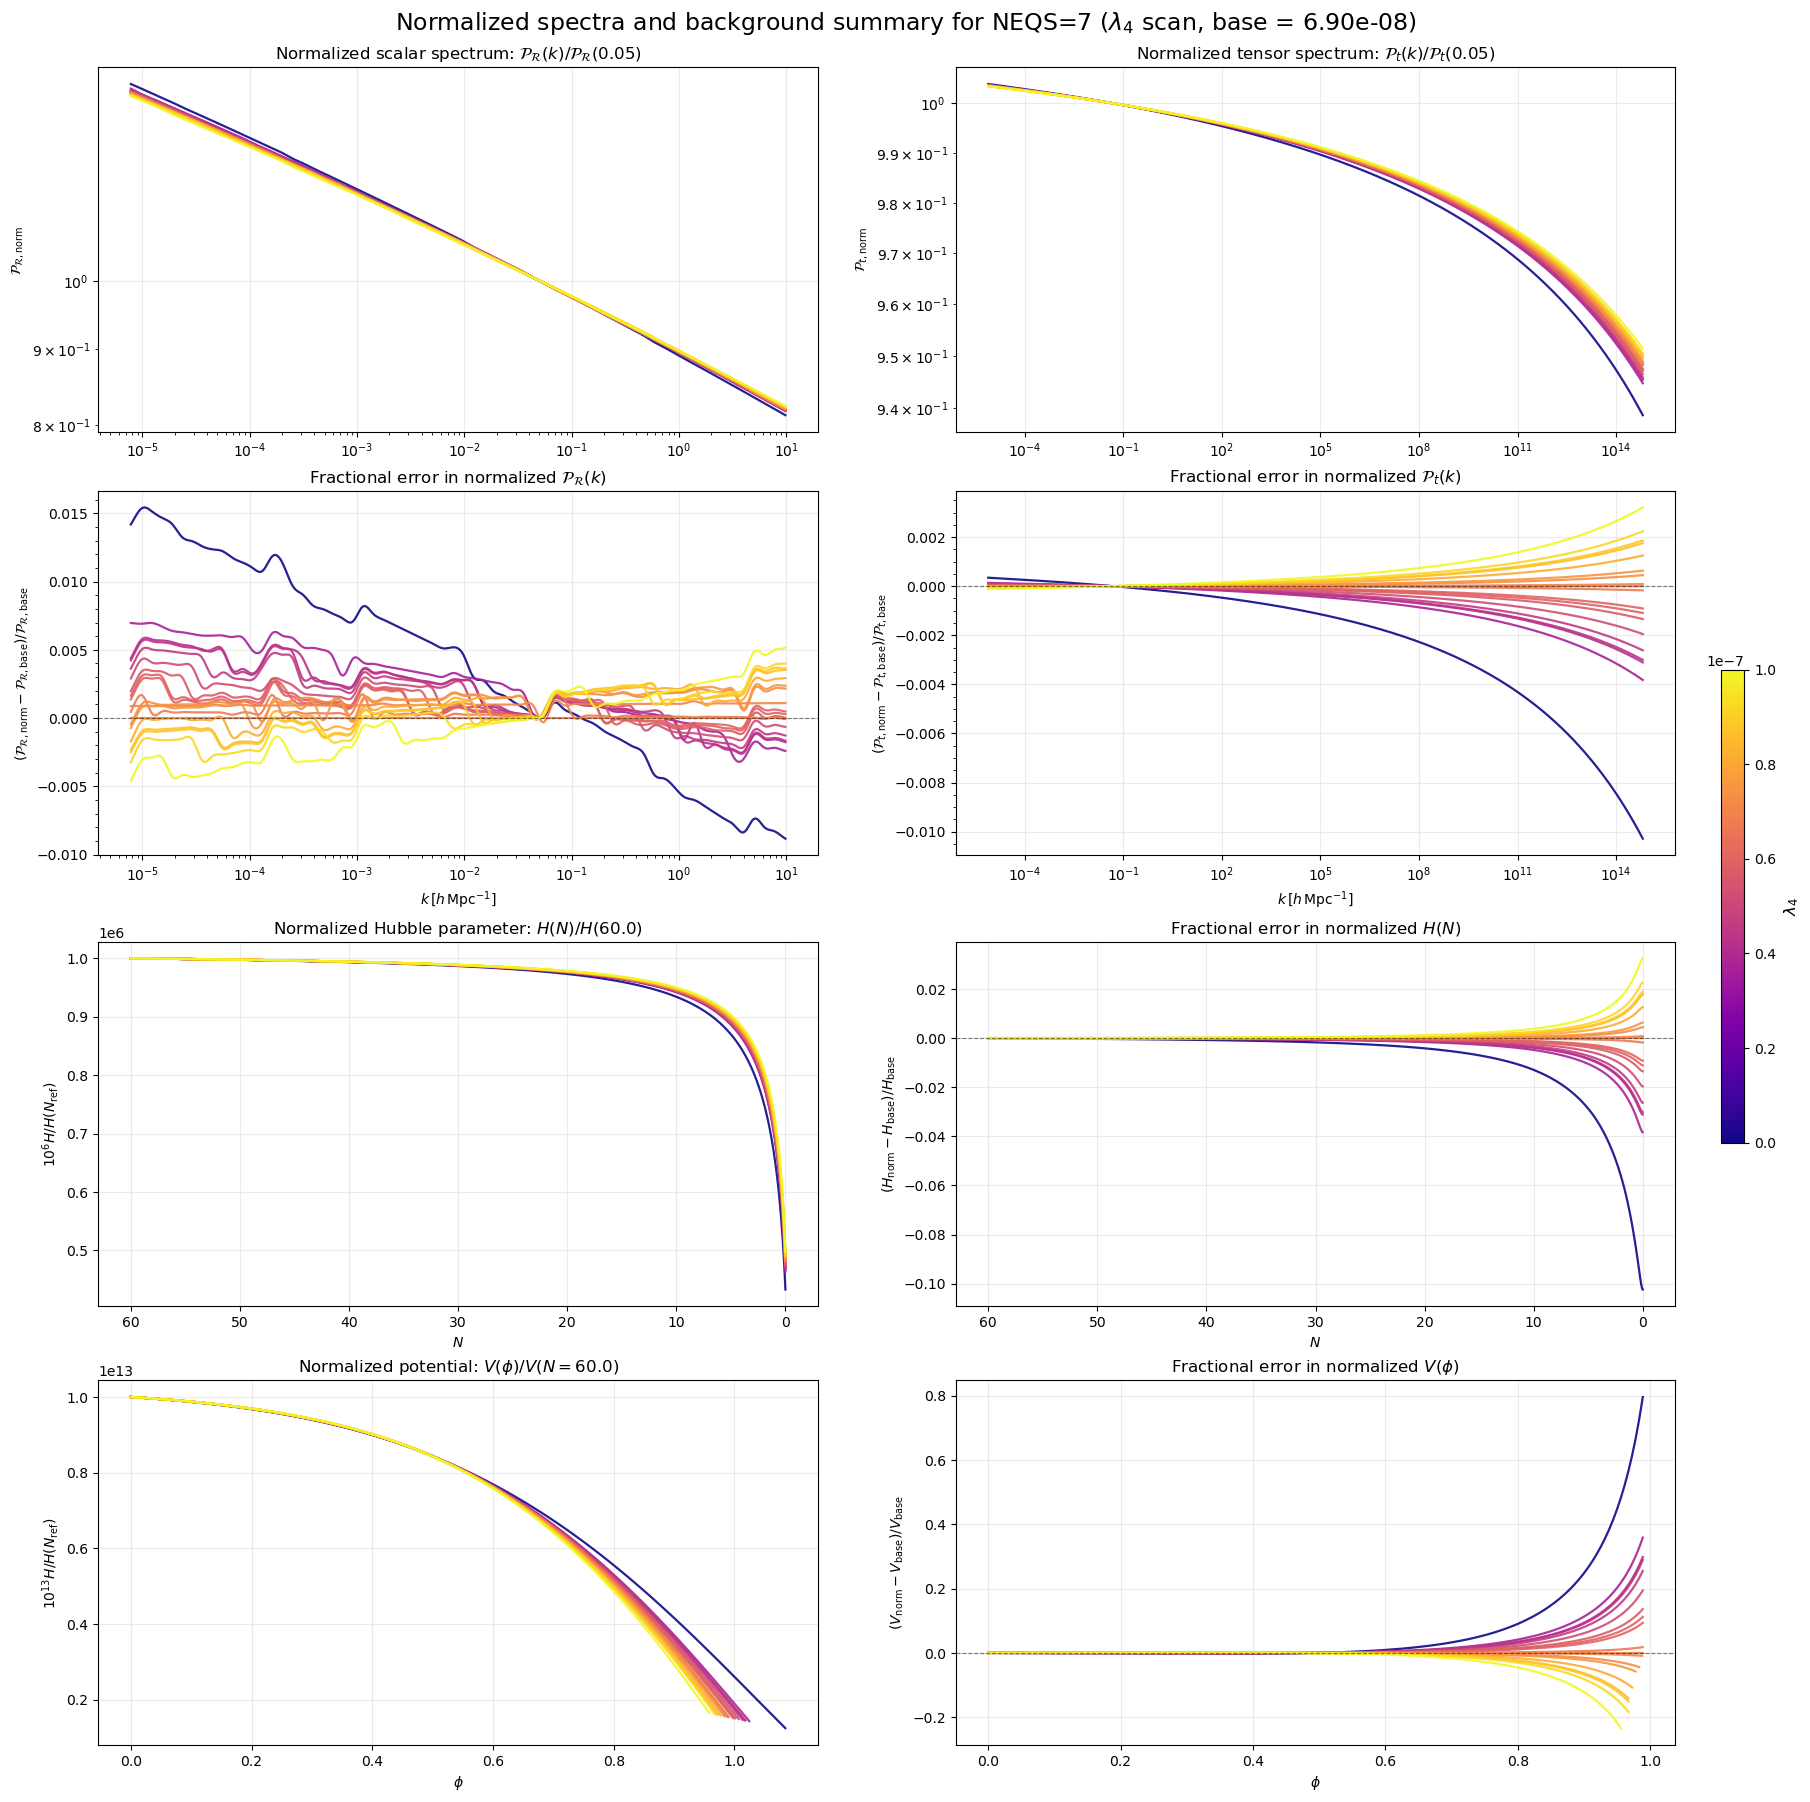

phi at max N: 0.0
phi at min N: 0.9887568
            lamX  mean_dPt_pct  max_dPt_pct  mean_dPs_pct  max_dPs_pct  \
0   0.000000e+00     -0.214986     1.028664      0.366481     1.543432   
1   3.700000e-08     -0.080708     0.382191      0.265780     0.697149   
2   4.200000e-08     -0.065713     0.310809      0.195768     0.588998   
3   4.300000e-08     -0.063546     0.300496      0.189198     0.574905   
4   4.600000e-08     -0.055315     0.261380      0.165940     0.515189   
5   5.200000e-08     -0.041310     0.194998      0.124610     0.436168   
6   5.700000e-08     -0.028415     0.134006      0.097490     0.355352   
7   5.900000e-08     -0.023170     0.109227      0.083071     0.320034   
8   6.000000e-08     -0.019258     0.090758      0.080336     0.294821   
9   6.700000e-08     -0.003613     0.017010      0.034439     0.184899   
10  6.900000e-08      0.000000     0.000000      0.000000     0.000000   
11  7.000000e-08      0.001825     0.008594      0.096830     0.128635

In [27]:

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam4_values = get_param_values_from_dirs(7, "lam4", base_path_root)


stats_df = plot_big_normalized_scan_summary(
    NEQS=7,
    lamX_values=lam4_values,
    baseX=6.9e-08,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    H_scale=1e6,    
    V_scale=1e13,    
    save_name="moderate_neqs7_lam4_big_summary.png"
)

print(stats_df)

## NEQs = 8 and $\lambda_5$:


Summary for NEQS=8, parameter=lam5
Total models found: 22
Parameter range: -8.900e-09 to 2.400e-06

Missing files for lam5 = 2.30000e-07
Missing files for lam5 = 2.60000e-07
Missing files for lam5 = 3.50000e-07
Missing files for lam5 = 3.80000e-07
Missing files for lam5 = 5.00000e-07
Missing files for lam5 = 5.50000e-07
Missing files for lam5 = 6.30000e-07
Missing files for lam5 = 6.60000e-07
Missing files for lam5 = 6.90000e-07
Missing files for lam5 = 7.10000e-07
Missing files for lam5 = 7.90000e-07
Missing files for lam5 = 1.20000e-06
Missing files for lam5 = 1.30000e-06
Missing files for lam5 = 1.40000e-06
Missing files for lam5 = 1.60000e-06
Missing files for lam5 = 1.70000e-06
Missing files for lam5 = 1.90000e-06
Missing files for lam5 = 2.00000e-06
Missing files for lam5 = 2.20000e-06
Missing files for lam5 = 2.40000e-06

=== Summary Statistics (% difference from base) ===

     lamX mean_dPt_pct max_dPt_pct mean_dPs_pct max_dPs_pct mean_dH_pct max_dH_pct mean_dV_pct max_dV_pct

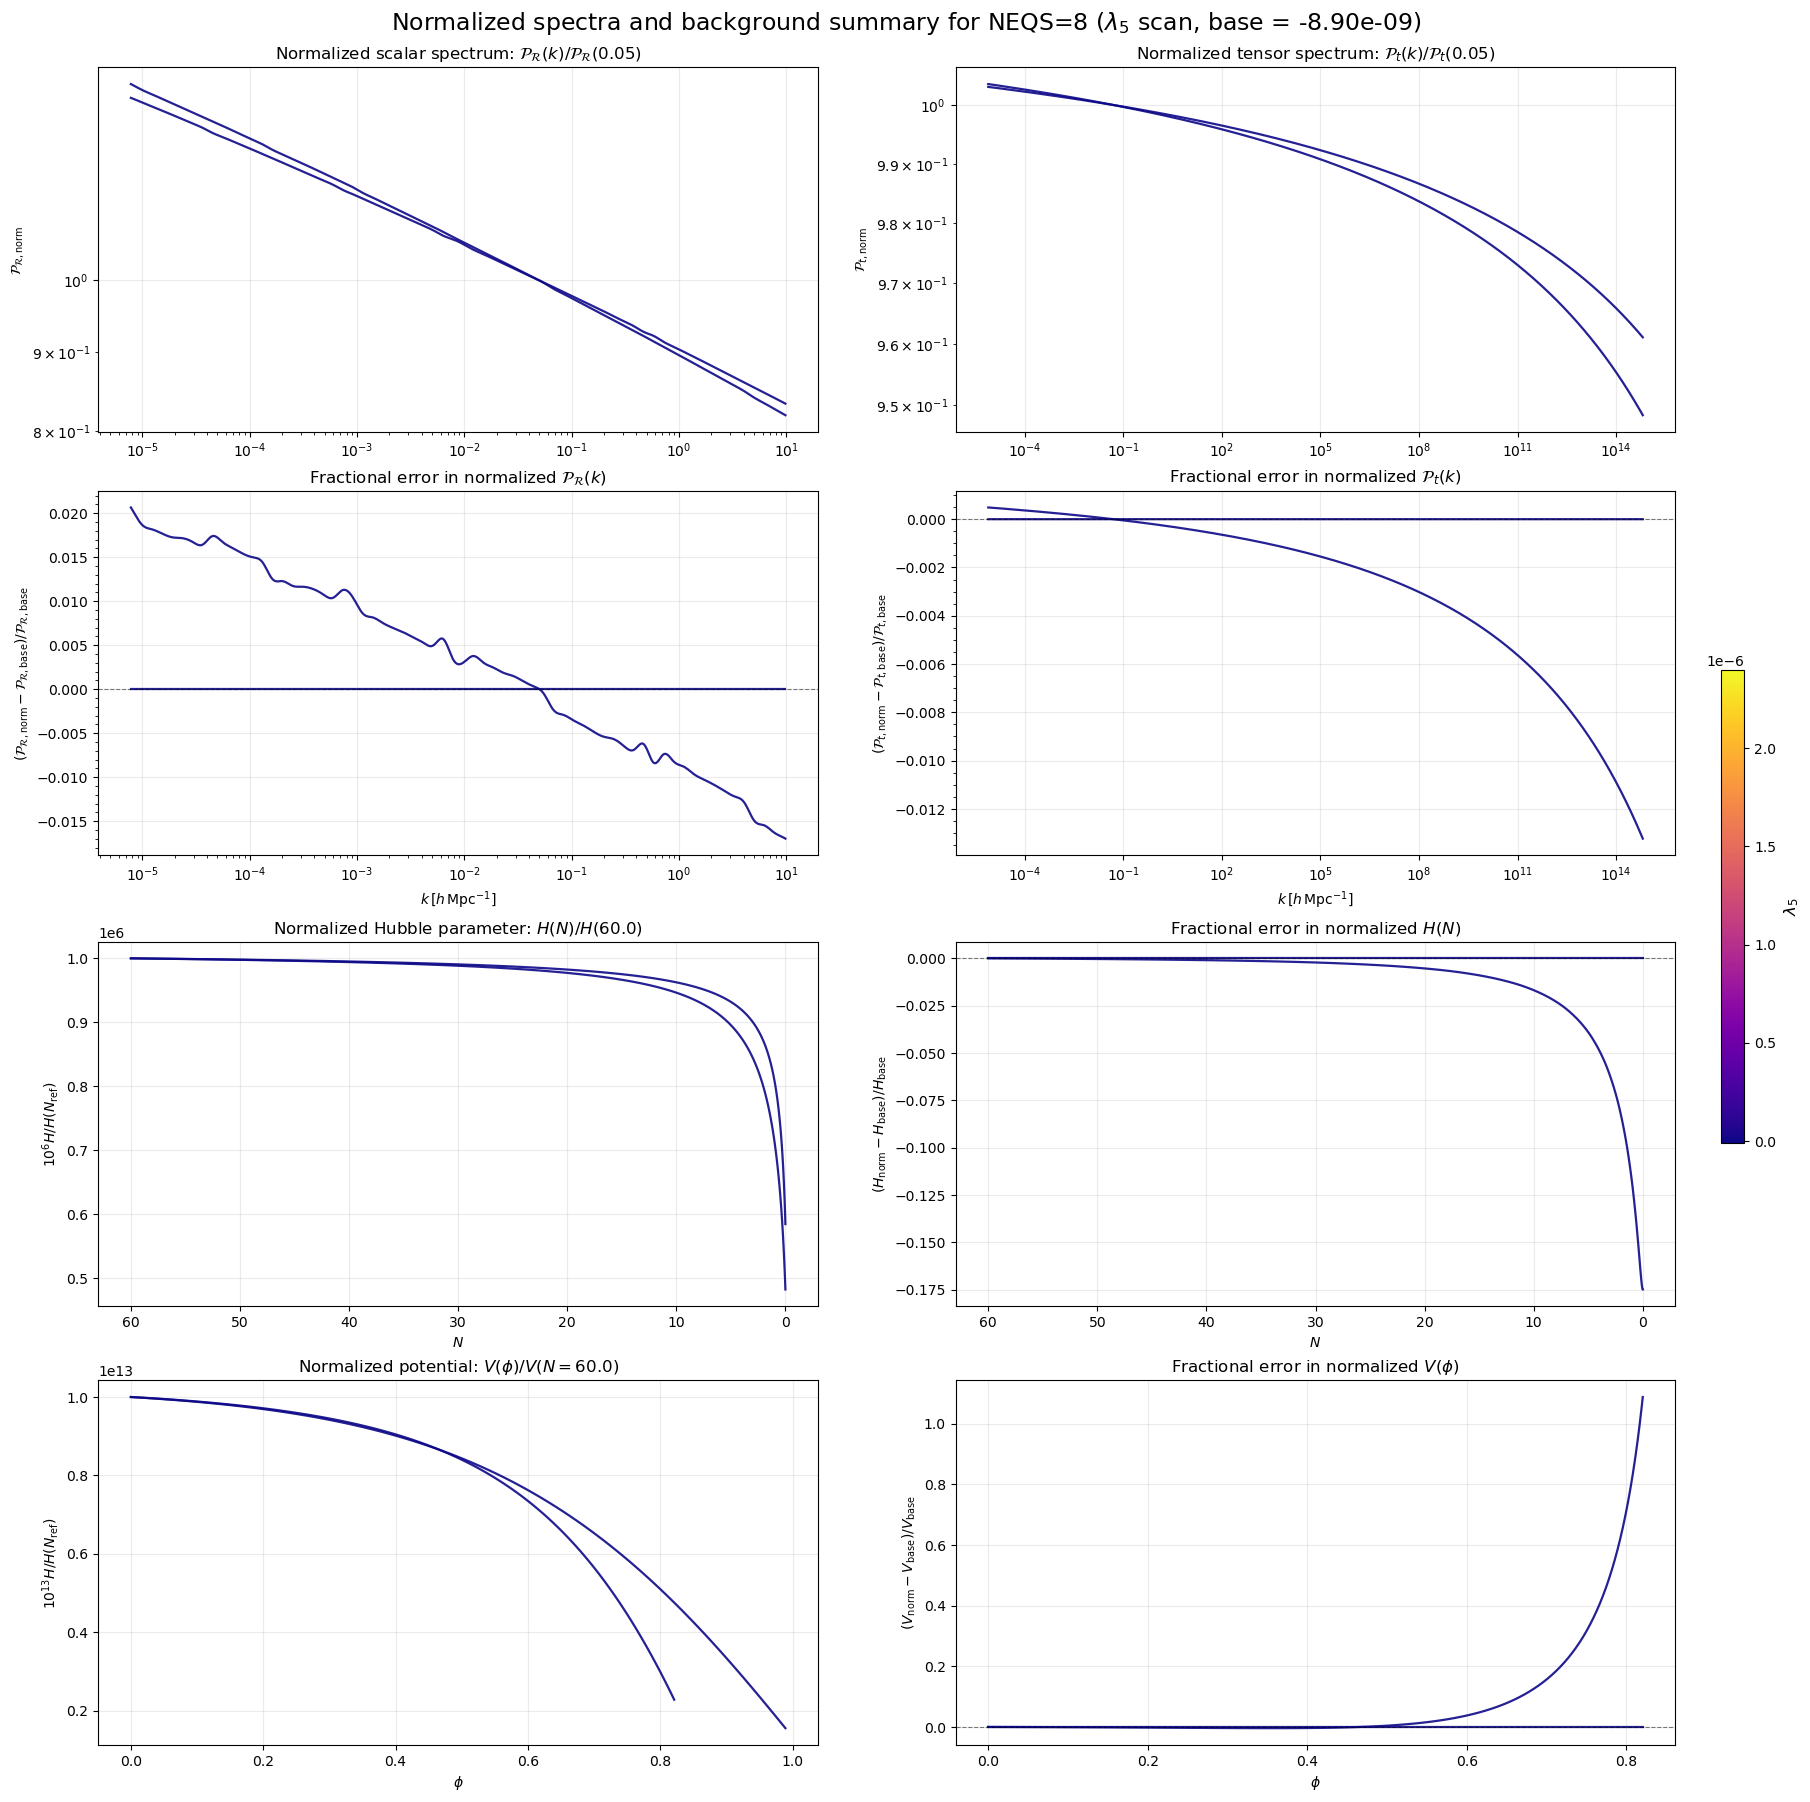

phi at max N: 0.0
phi at min N: 0.820774
           lamX  mean_dPt_pct  max_dPt_pct  mean_dPs_pct  max_dPs_pct  \
0 -8.900000e-09      0.000000     0.000000      0.000000     0.000000   
1  0.000000e+00     -0.280925     1.323012      0.315584     2.064683   

   mean_dH_pct  max_dH_pct  mean_dV_pct  max_dV_pct  
0      0.00000    0.000000     0.000000    0.000000  
1     -7.82776   17.492373    18.684715  108.743602  


In [31]:

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam5_values = get_param_values_from_dirs(8, "lam5", base_path_root)


stats_df = plot_big_normalized_scan_summary(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.9e-09,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    H_scale=1e6,    
    V_scale=1e13,    
    save_name="moderate_neqs8_lam5_big_summary.png"
)

print(stats_df)